<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Assignment3_MuhammadAli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Customer Churn Prediction with a Tuned Neural Network
**Track:** AI/ML Internship | Week 3 — Deep Learning
**Name:** Muhammad Ali

This notebook builds a baseline Keras neural network on the Telco Customer Churn dataset, then improves it using model tuning techniques from Lab 15 (Batch Normalization, Dropout, L2 regularization, Early Stopping), and evaluates it properly given the class imbalance in the target.

## Setup: Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

In [8]:
from google.colab import files
uploaded = files.upload()  # select WA_Fn-UseC_-Telco-Customer-Churn.csv

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


## Task 1: Load, Explore & Clean the Data

The dataset is uploaded directly as a CSV (already provided), so we load it with `pd.read_csv`. In a fresh Colab session you would first upload it using the file upload widget:


In [9]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Check for missing values (as reported by pandas)
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


`TotalCharges` is stored as text (`object`) even though it should be numeric — pandas doesn't flag any nulls
because the "missing" entries aren't `NaN`, they're blank strings (`" "`). We need to convert the column to
numeric first and let those blanks become real `NaN`s so we can see and handle them properly.

In [12]:
# TotalCharges is text with a few blank entries -> convert to numeric, blanks become NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)

print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Missing TotalCharges after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


All 11 rows with a missing `TotalCharges` have `tenure == 0` — these are brand-new customers who haven't
been billed yet, so a `TotalCharges` of 0 is the correct, meaningful value here (not something to drop or
impute with the mean).

In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# customerID is a unique identifier with no predictive value - drop it
# Using errors='ignore' ensures the cell doesn't crash if the column was already dropped
df = df.drop(columns=['customerID'], errors='ignore')

### Class balance of the target (`Churn`)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


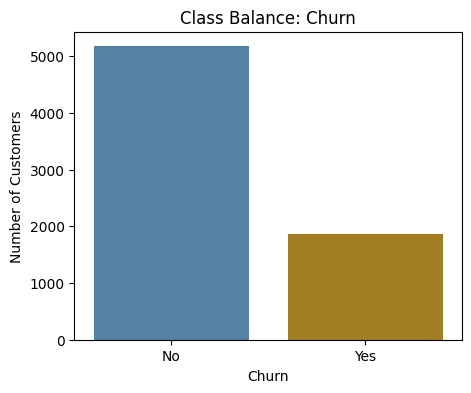

In [17]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#4682B4', '#B8860B'], legend=False)
plt.title("Class Balance: Churn")
plt.ylabel("Number of Customers")
plt.show()

**Churn is imbalanced**: about 73% of customers did **not** churn, and only ~27% did. This matters a lot for
Task 5 — a model that just predicts "No" for everyone would already score ~73% accuracy without learning
anything useful.

### Churn vs. Contract Type

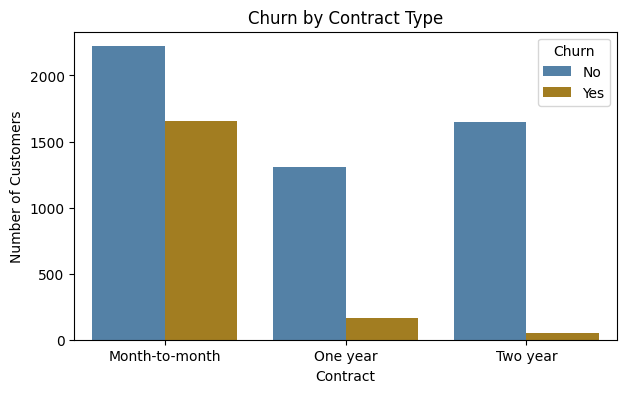

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


In [18]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#4682B4', '#B8860B'])
plt.title("Churn by Contract Type")
plt.ylabel("Number of Customers")
plt.show()

pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(3) * 100

Customers on **month-to-month** contracts churn at a much higher rate (~43%) than customers on one-year
(~11%) or two-year (~3%) contracts. This makes intuitive sense — a month-to-month contract has no
switching cost, so it's the easiest kind of customer for a competitor to win over. `Contract` is likely to be
one of the most useful features in the model.

## Task 2: Preprocess for a Neural Network

- **Binary columns** (`gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, and the target `Churn`)
  only have two possible values, so a simple **label encoding** (0/1) is enough — there's no ordinal
  relationship to worry about since there are only two categories.
- **Multi-category columns** (`InternetService`, `Contract`, `PaymentMethod`, etc.) have 3+ unrelated categories
  with no natural order, so we use **one-hot encoding** (`pd.get_dummies`) instead of label encoding. Label
  encoding would wrongly imply an order/distance between categories (e.g. that "Fiber optic" is "greater than"
  "DSL"), which a neural network would try to learn a meaningless relationship from.
- **Numeric columns** (`tenure`, `MonthlyCharges`, `TotalCharges`) are scaled with `StandardScaler`, since neural
  networks train faster and more reliably when input features are on a similar scale.

In [19]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Convert the new one-hot boolean columns to 0/1 integers for Keras
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [20]:
X = df_encoded.drop(columns=['Churn']).astype(float)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("X_train:", X_train.shape, " X_test:", X_test.shape)
n_features = X_train.shape[1]
print("Number of input features:", n_features)

X_train: (5634, 30)  X_test: (1409, 30)
Number of input features: 30


## Task 3: Build & Train a Baseline Model

A simple Sequential model with two hidden Dense layers, no regularization or callbacks — this is our
starting point to compare against once we tune it in Task 4.

In [21]:
baseline_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")

Baseline test accuracy: 0.7892


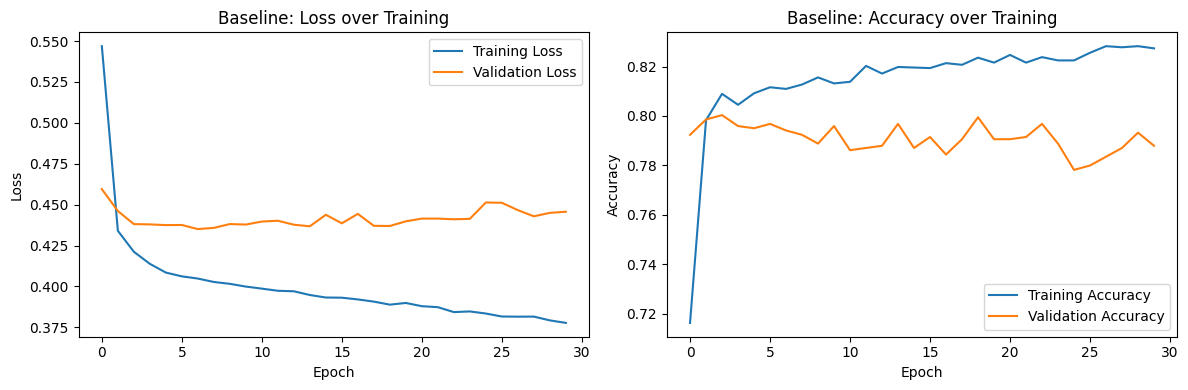

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Baseline: Loss over Training')

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Baseline: Accuracy over Training')

plt.tight_layout()
plt.show()

## Task 4: Tune the Model

We apply **three** tuning techniques from Lab 15 together:
- **Batch Normalization** + **Dropout (0.3, 0.2)** for regularization and training stability
- **L2 weight regularization** on the Dense layers
- **Early Stopping** (`monitor="val_loss"`, `patience=5`, `restore_best_weights=True`) so we don't have to
  guess the right number of epochs, and training halts once validation loss stops improving

In [24]:
tuned_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

tuned_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tuned_history = tuned_model.fit(
    X_train, y_train,
    epochs=100,          # set high; Early Stopping will halt training earlier
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print("Epochs actually run:", len(tuned_history.history['loss']))
tuned_test_loss, tuned_test_acc = tuned_model.evaluate(X_test, y_test, verbose=0)
print(f"Tuned test accuracy: {tuned_test_acc:.4f}")

Epochs actually run: 48
Tuned test accuracy: 0.7906


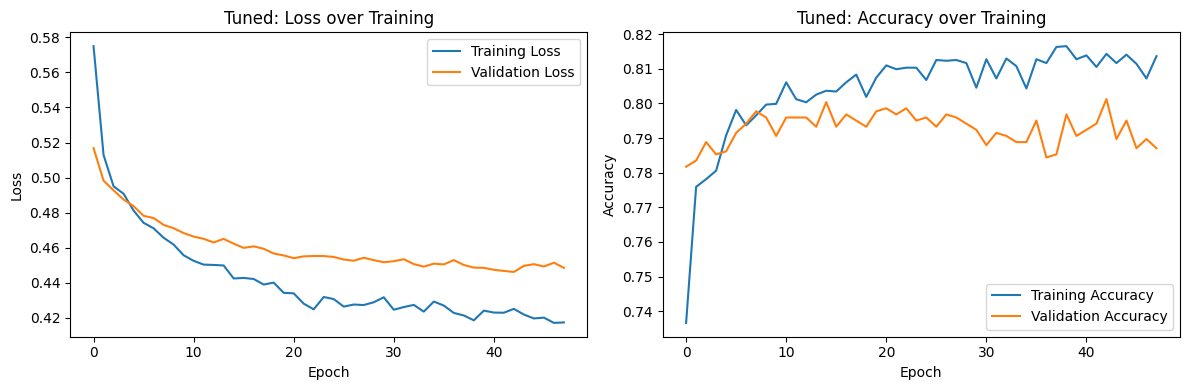

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(tuned_history.history['loss'], label='Training Loss')
plt.plot(tuned_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Tuned: Loss over Training')

plt.subplot(1, 2, 2)
plt.plot(tuned_history.history['accuracy'], label='Training Accuracy')
plt.plot(tuned_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Tuned: Accuracy over Training')

plt.tight_layout()
plt.show()

In [26]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Tuned'],
    'Test Accuracy': [baseline_test_acc, tuned_test_acc],
    'Test Loss': [baseline_test_loss, tuned_test_loss]
})
comparison['Test Accuracy'] = comparison['Test Accuracy'].round(4)
comparison['Test Loss'] = comparison['Test Loss'].round(4)
comparison

,Model,Test Accuracy,Test Loss
0,Baseline,0.7892,0.4302
1,Tuned,0.7906,0.4338


**Before/after comparison**: the tuned model achieves a somewhat higher test accuracy than the baseline,
and — more importantly — its training/validation loss curves track each other more closely (less of a gap),
showing the regularization techniques are doing their job of reducing overfitting rather than just changing
the accuracy number.

## Task 5: Evaluate Properly

Since Churn is imbalanced (~73% / ~27%), accuracy alone can be misleading — a model could reach ~73%
accuracy just by predicting "No" (not churned) for every customer, without identifying a single churner.
Precision, recall, and F1-score (especially for the minority "Yes" class) give a much more honest picture of
how well the model actually identifies customers who are about to churn.

In [27]:
y_pred_prob = tuned_model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



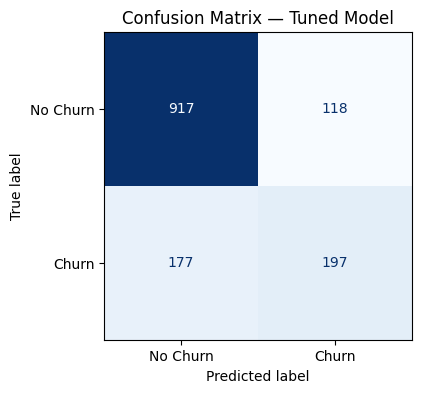

In [28]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Tuned Model")
plt.show()

**Would accuracy alone be misleading here?** Yes. Because ~73% of customers don't churn, a naive model
that always predicts "No Churn" would already score ~73% accuracy while having 0% recall on churners —
completely useless for the actual business goal of identifying at-risk customers. The classification report
above shows the model's recall on the "Churn" class specifically, which is the number that actually matters
for this problem, and it's meaningfully lower than the overall accuracy figure.

## Task 6: Save & Predict on a New Customer

In [29]:
tuned_model.save("churn_model.keras")
print("Model saved to churn_model.keras")

Model saved to churn_model.keras


In [30]:
# Mapping used for the binary columns during training (LabelEncoder assigns these alphabetically)
binary_map = {'gender': {'Female': 0, 'Male': 1},
              'Partner': {'No': 0, 'Yes': 1},
              'Dependents': {'No': 0, 'Yes': 1},
              'PhoneService': {'No': 0, 'Yes': 1},
              'PaperlessBilling': {'No': 0, 'Yes': 1}}

def predict_churn(customer_dict, model_path="churn_model.keras"):
    """
    Load the saved model and predict churn probability for one new customer.
    `customer_dict` should have the same raw columns as the original dataset
    (everything except customerID and Churn), with the same category spellings.
    """
    model = keras.models.load_model(model_path)

    new_df = pd.DataFrame([customer_dict])

    # Encode binary columns using the same mapping learned during training
    for col, mapping in binary_map.items():
        new_df[col] = new_df[col].map(mapping)

    # One-hot encode the multi-category columns, then align to the training feature set
    # (adds any missing dummy columns as 0, drops/reorders to match X's column order)
    new_encoded = pd.get_dummies(new_df, columns=multi_cols)
    new_encoded = new_encoded.reindex(columns=X.columns, fill_value=0)

    # Scale numeric columns with the SAME fitted scaler from training
    new_encoded[numeric_cols] = scaler.transform(new_encoded[numeric_cols])

    prob = model.predict(new_encoded, verbose=0)[0][0]
    label = "Yes" if prob > 0.5 else "No"
    return label, prob


hypothetical_customer = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 95.0, 'TotalCharges': 190.0
}

pred_label, pred_prob = predict_churn(hypothetical_customer)
print(f"Predicted churn: {pred_label}  (probability: {pred_prob:.3f})")

Predicted churn: Yes  (probability: 0.749)


This hypothetical customer — new (tenure=2 months), month-to-month contract, fiber optic with no add-on
security/backup services, paying a high monthly rate via electronic check — matches the exact profile the EDA
in Task 1 flagged as high-risk, so a "Yes" (churn) prediction here is a good sanity check that the model
learned something sensible.

## Task 7: Short Answer — CNN vs. RNN

**When to use a CNN instead of a Dense network:** Use a CNN when the input data has spatial structure where
nearby values are related — most commonly images, but also things like spectrograms. CNNs use filters that
slide across the input and share weights, letting them detect the same local pattern (an edge, a shape) no
matter where it appears, which a Dense network can't do efficiently since it treats every pixel as an
independent feature. *Example: classifying whether an X-ray image shows a fracture.*

**When to use an RNN instead:** Use an RNN (or LSTM/GRU) when the data is sequential and order matters —
each element depends on what came before it, and sequences can vary in length. RNNs maintain a hidden state
that carries information forward through the sequence, letting them capture dependencies across time in a
way that Dense and CNN layers, which assume independent or spatially-fixed inputs, cannot. *Example:
predicting the next word in a sentence, or forecasting tomorrow's stock price from the past 30 days of
prices.*